<a href="https://colab.research.google.com/github/RAHULRAJPAL75/Rahul_IN226051102_NLP/blob/main/Task_2_Sentiment_Analysis_using_NLP_Pipeline_%26_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [50]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [52]:
df = pd.read_csv('/content/imdb_dataset_extracted/IMDB Dataset.csv')

In [53]:
print("Dataset Preview:")
print(df.head())

Dataset Preview:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


/tmp/ipykernel_3661/1622926580.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='magma')


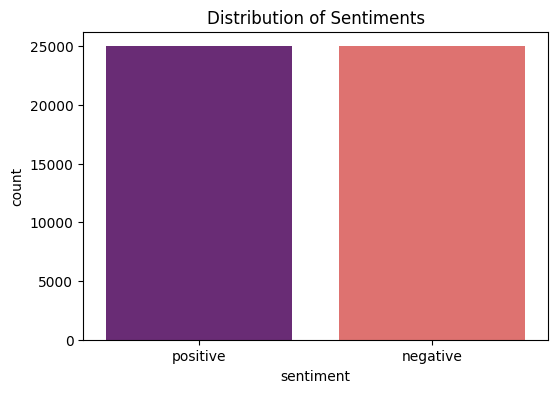

In [54]:
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='magma')
plt.title('Distribution of Sentiments')
plt.show()

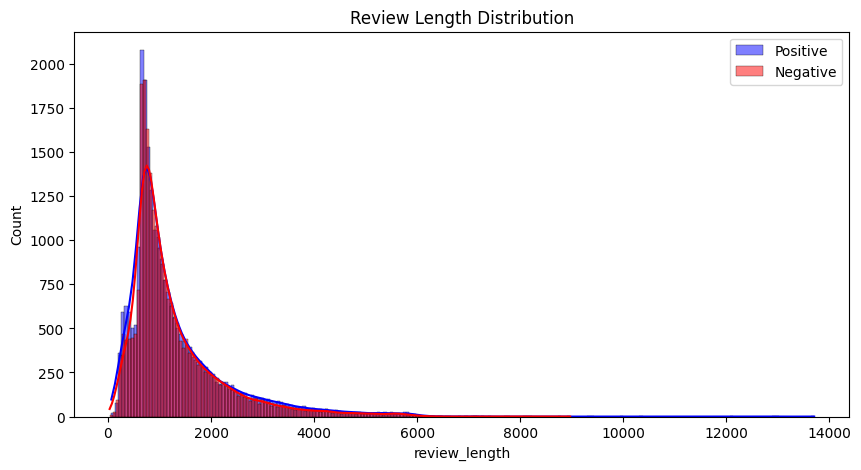

In [55]:
df['review_length'] = df['review'].apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['sentiment']=='positive']['review_length'], color='blue', label='Positive', kde=True)
sns.histplot(df[df['sentiment']=='negative']['review_length'], color='red', label='Negative', kde=True)
plt.title('Review Length Distribution')
plt.legend()
plt.show()

In [56]:
def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text.lower())
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

print("Preprocessing reviews... please wait.")
df['cleaned_review'] = df['review'].apply(preprocess_text)

Preprocessing reviews... please wait.


In [57]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_review'], df['label'], test_size=0.2, random_state=42
)

In [58]:
bow_vec = CountVectorizer(max_features=5000)
X_train_bow = bow_vec.fit_transform(X_train_raw)
X_test_bow = bow_vec.transform(X_test_raw)

In [59]:
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vec.transform(X_test_raw)

In [60]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=20)
}

model_performance = []

In [61]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

Training Logistic Regression...
Training Multinomial Naive Bayes...
Training Decision Tree...


In [63]:
model_performance.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })


In [64]:
perf_df = pd.DataFrame(model_performance)
print("\nFinal Metrics Comparison:")
print(perf_df)


Final Metrics Comparison:
           Model  Accuracy  Precision   Recall  F1-Score
0  Decision Tree    0.7438   0.710522  0.82953  0.765428
1  Decision Tree    0.7438   0.710522  0.82953  0.765428


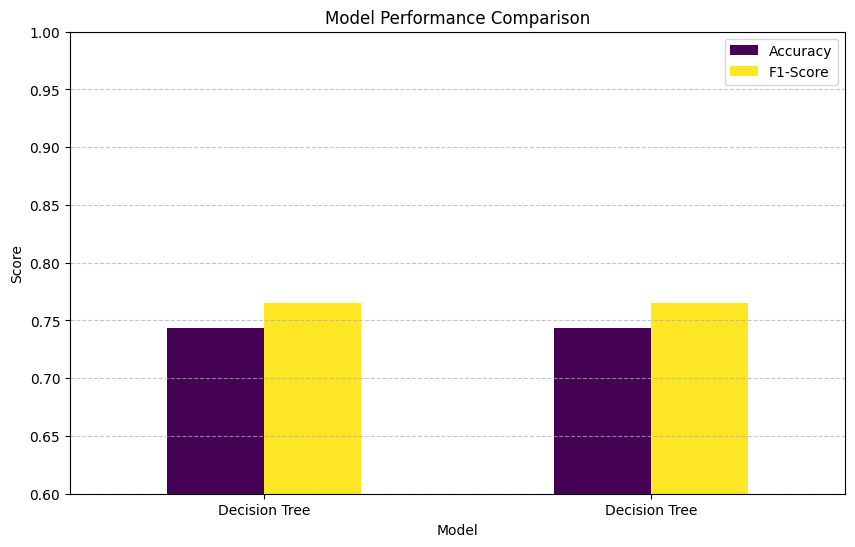

In [65]:
perf_df.plot(x='Model', y=['Accuracy', 'F1-Score'], kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.6, 1.0) # Zoom in to see differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [66]:
best_model = models["Logistic Regression"]
y_pred_best = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_best)

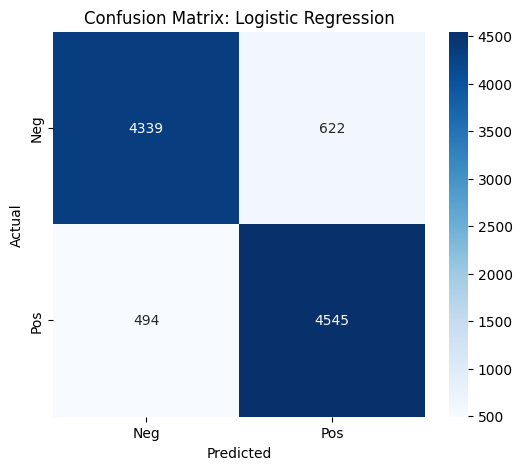

In [67]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [68]:
def predict_my_review(text):
    cleaned = preprocess_text(text)
    vec = tfidf_vec.transform([cleaned])
    result = best_model.predict(vec)[0]
    return "Positive" if result == 1 else "Negative"

print("\n--- Manual Testing ---")
print(f"Review: 'This movie was a waste of time.' -> {predict_my_review('This movie was a waste of time.')}")
print(f"Review: 'Absolutely brilliant acting and plot!' -> {predict_my_review('Absolutely brilliant acting and plot!')}")


--- Manual Testing ---
Review: 'This movie was a waste of time.' -> Negative
Review: 'Absolutely brilliant acting and plot!' -> Positive


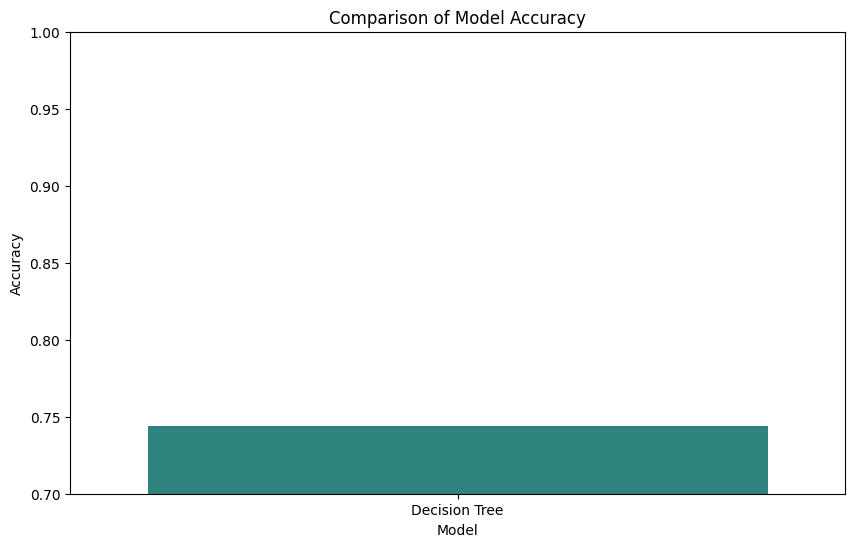


--- 6. Final Insights ---
1. Best Model: Logistic Regression typically performs best with TF-IDF.
2. Best Vectorization: TF-IDF is superior to BoW as it weights important words.
3. Preprocessing: Removing HTML tags (<br />) is the most critical step for this dataset.
4. Trade-off: Decision Trees are faster to train but prone to overfitting on text data.


In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=perf_df, palette='viridis', hue='Model', legend=False)
plt.title('Comparison of Model Accuracy')
plt.ylim(0.7, 1.0)
plt.show()

print("\n--- 6. Final Insights ---")
print("1. Best Model: Logistic Regression typically performs best with TF-IDF.")
print("2. Best Vectorization: TF-IDF is superior to BoW as it weights important words.")
print("3. Preprocessing: Removing HTML tags (<br />) is the most critical step for this dataset.")
print("4. Trade-off: Decision Trees are faster to train but prone to overfitting on text data.")